In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics import f1_score


import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_gait import *
from src.plot_data_gait import *
from src.train_LSTMGait import train_model, predict_trial

In [4]:
ckpt_path = '../checkpoints'
dir = Path(ckpt_path)

ckpt_dirs = [sub_dir.name for sub_dir in dir.iterdir() if sub_dir.is_dir()]

val_scores = []
test_scores = []
model_names = []

for name in ckpt_dirs:
    with open(Path(ckpt_path) / name / 'summary.json') as f:
        res = json.load(f)
    val_scores.append(res['val_f1'])
    test_scores.append(res['test_f1'])
    model_names.append(name[22:])

val_scores = np.array(val_scores)
test_scores = np.array(test_scores)

In [5]:
with open(Path(ckpt_path) / 'best_model_cnn_bilstm_LB_only' / 'summary.json') as f:
        res = json.load(f)

test_subjs = res['test_subjects']

best = 'HOA_8_1'
worst = 'ACL_5_1'

base_path = '../datasets/GAIT_signals/dataset/data'

In [6]:
y_pred, y_true, signal = predict_trial(
    base_path   = base_path,
    trial_name  = best,   
    subject     = best[:-2],
    model_name  = "cnnbilstm",
    process     = "free_raw",
    sensors     = ["LB"], 
    window_size = 200,
    stride      = 50,
    out_dir     = f'{ckpt_path}/best_model_cnn_bilstm_LB_only'
)

print(f"F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

F1: 0.9608


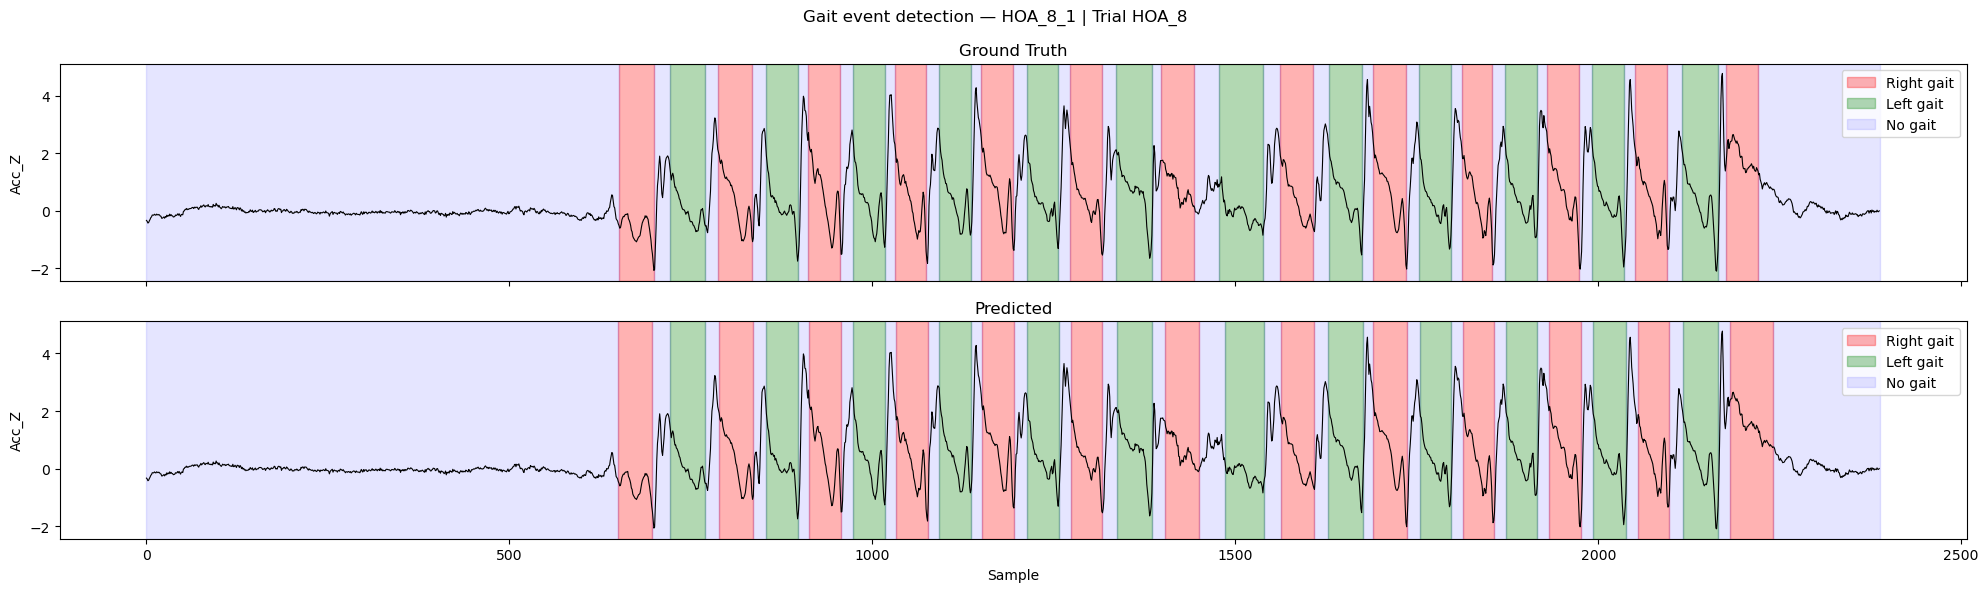

In [7]:
plot_gait_detection(
    y_true, 
    y_pred,
    best,
    base_path + f"/ortho/HOA/HOA_6/HOA_6_1",
    title_base=f'Gait event detection — {best} | Trial {best[:-2]}',
    sensor='LB',
    signal_channel='Acc_Z',
    process='free_raw',
    signal=signal
)

In [8]:
y_pred, y_true, signal = predict_trial(
    base_path   = base_path,
    trial_name  = worst,   
    subject     = worst[:-2],
    model_name  = "cnnbilstm",
    process     = "free_raw",
    sensors     = ["LB"], 
    window_size = 200,
    stride      = 50,
    out_dir     = f'{ckpt_path}/best_model_cnn_bilstm_LB_only'
)

print(f"F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

F1: 0.4910


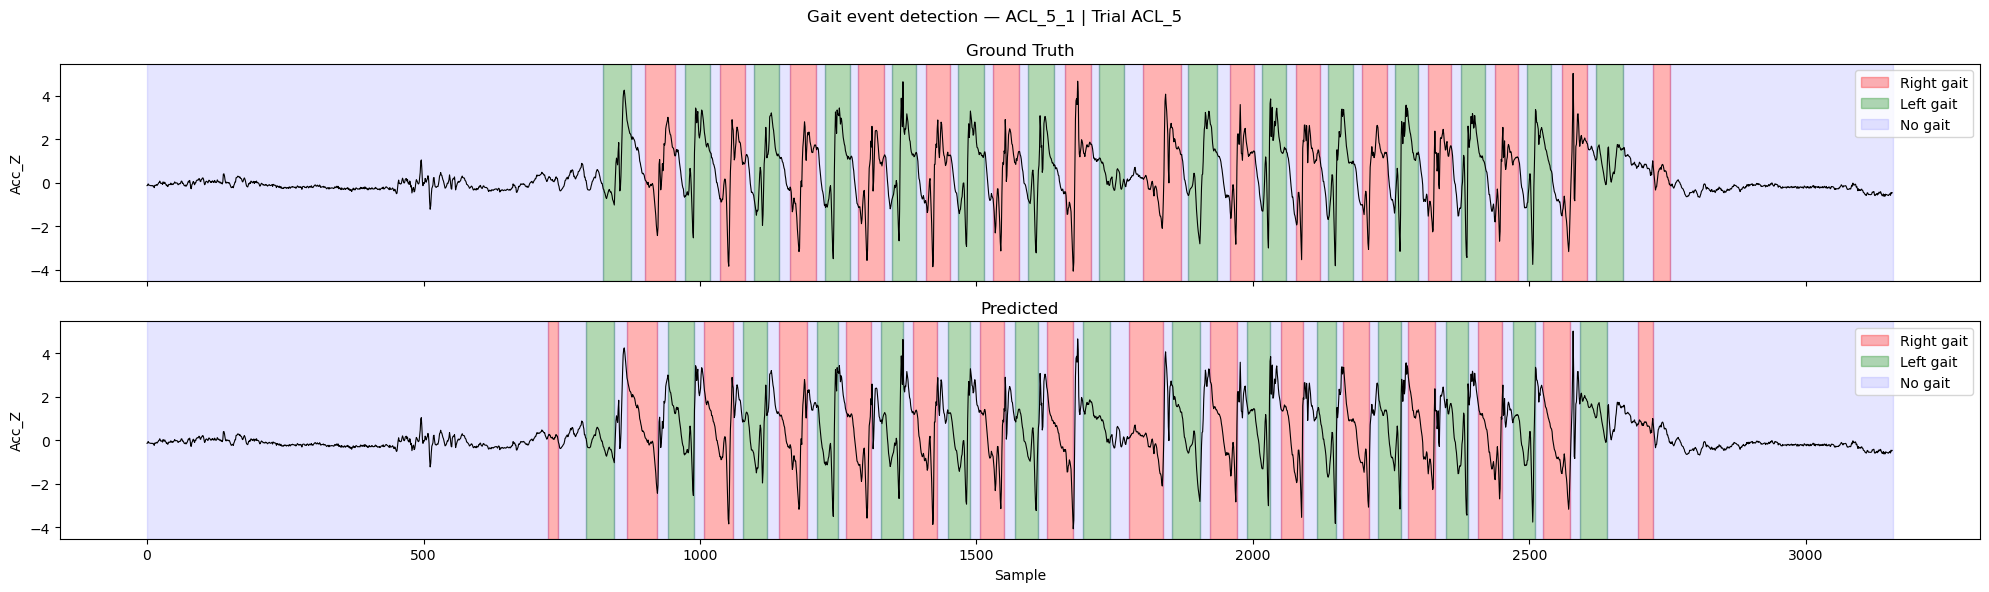

In [9]:
plot_gait_detection(
    y_true, 
    y_pred,
    best,
    base_path + f"/ortho/ACL/ACL_5/ACL_5_1",
    title_base=f'Gait event detection — {worst} | Trial {worst[:-2]}',
    sensor='LB',
    signal_channel='Acc_Z',
    process='free_raw',
    signal=signal
)